In [27]:
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
# Load the Excel file
file_path = 'Mobile sales/Mobile Sales Data.xlsx'
xls = pd.ExcelFile(file_path)

In [31]:
# Show available sheet names (optional)
print(xls.sheet_names)

['Mobile sales']


In [33]:
# Load the first sheet (or choose by name)
df = xls.parse(xls.sheet_names[0])

In [34]:
# Preview the data
df.head()

,Transaction ID,Day,Month,Year,Day Name,Brand,Units Sold,Price Per Unit,Customer Name,Customer Age,City,Payment Method,Customer Ratings,Mobile Model
0,1,9,10,2021,Sat,Xiaomi,6,10174.70,Lalita Ahuja,38,Ludhiana,UPI,5,Redmi Note 10
1,2,9,10,2021,Saturday,Vivo,6,10565.19,Sneha Sharma,37,Delhi,Credit Card,3,Vivo Y51
2,3,9,10,2021,Saturday,Vivo,8,58527.58,Radha Srivastava,40,Mumbai,UPI,5,Vivo S1
3,4,10,10,2021,Sunday,Xiaomi,5,25563.98,Bhavana Arora,21,Mumbai,Credit Card,4,Mi 11
4,5,10,10,2021,Sunday,OnePlus,3,48168.02,Sneha Mehta,38,Gorakhpur,Cash,5,OnePlus 9


In [37]:
print(df.columns.tolist())

['Transaction ID', 'Day', 'Month', 'Year', 'Day Name', 'Brand', 'Units Sold', 'Price Per Unit', 'Customer Name', 'Customer Age', 'City', 'Payment Method', 'Customer Ratings', 'Mobile Model']


In [39]:
# Combine Year, Month, Day into a Date column
df['date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# Create a month column from the date
df['month'] = df['date'].dt.to_period('M')

# Calculate total price per transaction
df['total_price'] = df['Units Sold'] * df['Price Per Unit']


In [41]:
# Group by month and calculate total sales
monthly_sales = df.groupby('month')['total_price'].sum()


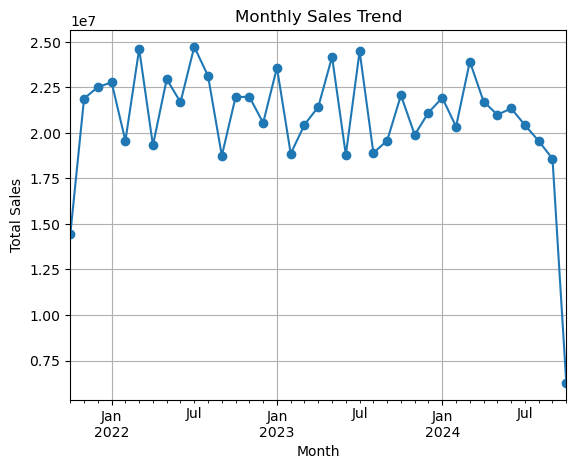

In [43]:
# Plot sales trend
monthly_sales.plot(kind='line', marker='o', title='Monthly Sales Trend')
plt.ylabel('Total Sales')
plt.xlabel('Month')
plt.grid(True)
plt.show()

In [48]:
#Top-Selling Mobile Models
model_sales = df.groupby('Mobile Model')['Units Sold'].sum().sort_values(ascending=False)
print(model_sales.head(10))  # Top 10 models

Mobile Model
iPhone SE         1430
Vivo Y51          1429
OnePlus Nord      1409
Galaxy Note 20    1382
Galaxy S21        1305
Mi 11             1285
iPhone 11         1263
Redmi Note 10     1251
iPhone 12         1239
Vivo V20          1237
Name: Units Sold, dtype: int64


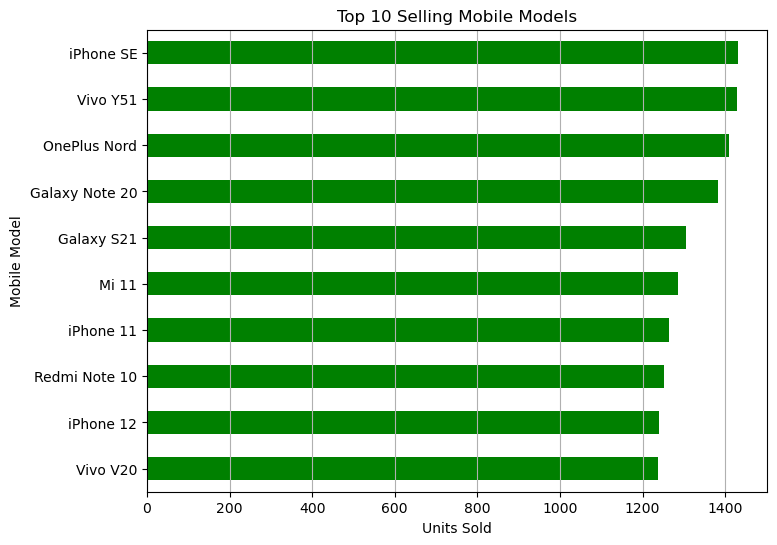

In [50]:
model_sales.head(10).plot(kind='barh', title='Top 10 Selling Mobile Models', figsize=(8, 6), color='green')
plt.xlabel('Units Sold')
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.show()